# Replenishment of low-selling items without forecast

In this notebook, we present how to simply perform data-driven replenishment of low-selling items with intermittent demand for which demand forecast is not usable in practice.

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import poisson, binom, nbinom

## 1. Generation of an intermittent sales history

Generated 104 values from a Poisson distribution with lambda=0.2:


Text(0, 0.5, 'Weekly sales')

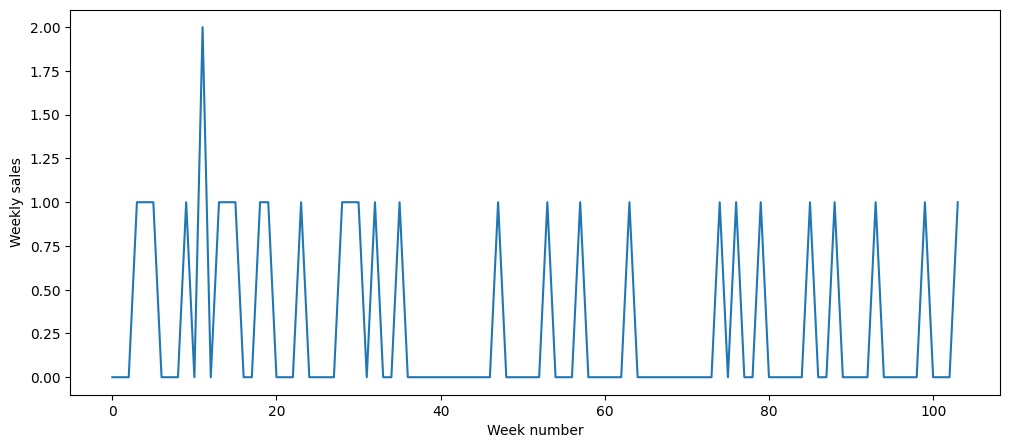

In [52]:
# Parameters for the Poisson distribution
poisson_lambda = 0.2  # The average number of events in an interval
num_samples = 104  # The number of values to generate

# Generate a list of values following a Poisson distribution
poisson_values = np.random.poisson(poisson_lambda, num_samples)

print(f"Generated {num_samples} values from a Poisson distribution with lambda={poisson_lambda}:")

plt.figure(figsize=(12, 5))
plt.plot(poisson_values)
plt.xlabel("Week number")
plt.ylabel("Weekly sales")

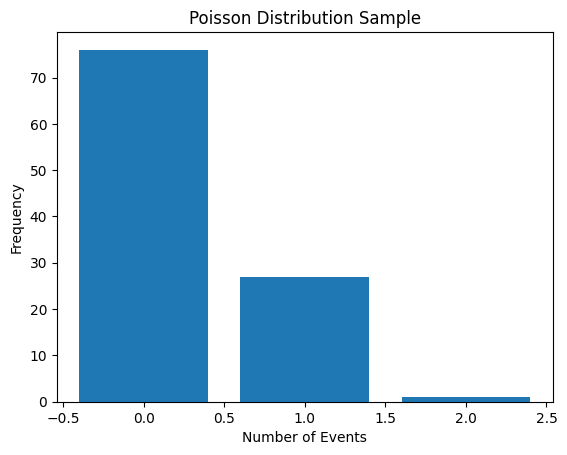

In [53]:
# You can also visualize the distribution (requires matplotlib)
plt.hist(poisson_values, bins=range(max(poisson_values) + 2), align='left', rwidth=0.8)
plt.title('Poisson Distribution Sample')
plt.xlabel('Number of Events')
plt.ylabel('Frequency')
plt.show()

## 2. Fit of the sales pattern with a Poisson or Binomial distribution

In [54]:
# Calculate the mean of the poisson_values array
mean_poisson_values = np.mean(poisson_values)

# Calculate the variance of the poisson_values array
variance_poisson_values = np.var(poisson_values)

print(f"Mean of poisson_values: {mean_poisson_values:.4f}")
print(f"Variance of poisson_values: {variance_poisson_values:.4f}")

Mean of poisson_values: 0.2788
Variance of poisson_values: 0.2203


In [55]:
# For plotting range, consider the maximum value in poisson_values
max_val = int(np.max(poisson_values)) if len(poisson_values) > 0 else 5
x = np.arange(0, max_val + 3) # Range for PMF plots

# --- Poisson Distribution PMF ---
# Use the observed mean from the samples for theoretical Poisson PMF
poisson_pmf = poisson.pmf(x, mu=mean_poisson_values)

# --- Binomial Distribution PMF ---
# To approximate with a binomial, we'll match the mean and choose a small 'p'.
# Let's set a small 'p' and calculate 'n' to match the mean.
# n * p = mean_poisson_values => n = mean_poisson_values / p
p_binomial = 0.05 # A small probability for binomial approximation
n_binomial = int(round(mean_poisson_values / p_binomial))

# Ensure n_binomial is at least 1 and p_binomial is valid
if n_binomial <= 0:
    n_binomial = 1 # Fallback to a minimum n

# Calculate binomial PMF
binomial_pmf = binom.pmf(x, n=n_binomial, p=p_binomial)

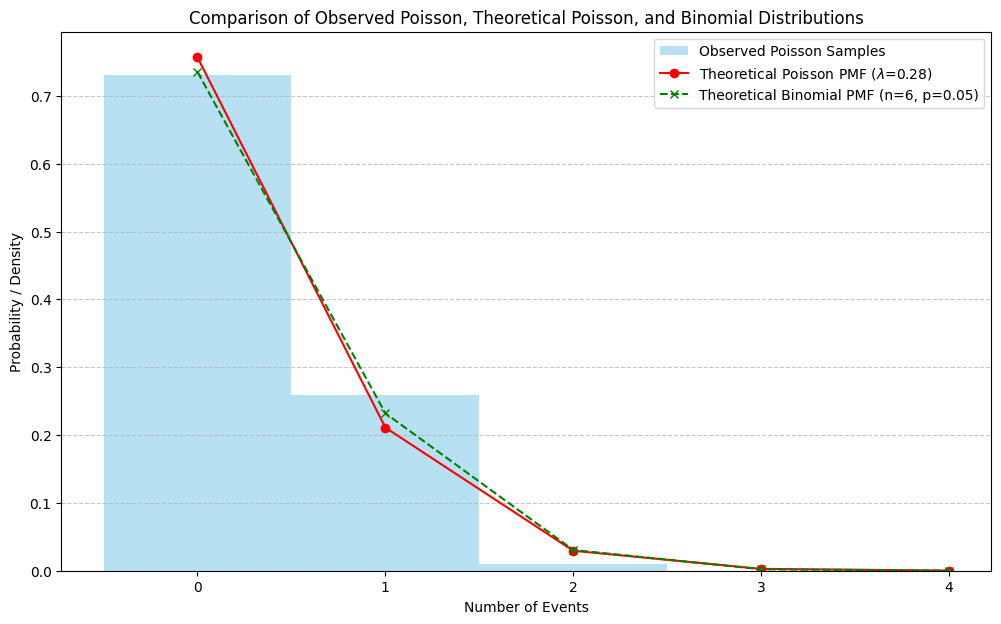

Derived Binomial Parameters: n=6, p=0.05
  Binomial Mean: 0.3000
  Binomial Variance: 0.2850


In [56]:
# --- Plotting ---
plt.figure(figsize=(12, 7))
plt.hist(
    poisson_values,
    bins=np.arange(-0.5, max_val + 2.5),
    density=True, alpha=0.6, color='skyblue', label='Observed Poisson Samples'
)
plt.plot(x, poisson_pmf, 'o-', color='red', label=f'Theoretical Poisson PMF ($\lambda$={mean_poisson_values:.2f})')
plt.plot(x, binomial_pmf, 'x--', color='green', label=f'Theoretical Binomial PMF (n={n_binomial}, p={p_binomial:.2f})')

plt.title('Comparison of Observed Poisson, Theoretical Poisson, and Binomial Distributions')
plt.xlabel('Number of Events')
plt.ylabel('Probability / Density')
plt.xticks(np.arange(0, max_val + 3))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Derived Binomial Parameters: n={n_binomial}, p={p_binomial}")
print(f"  Binomial Mean: {n_binomial * p_binomial:.4f}")
print(f"  Binomial Variance: {n_binomial * p_binomial * (1 - p_binomial):.4f}")

## 3. Compute order quantities

In [ ]:
def calculate_order_quantity(
    current_inventory,
    stock_in_transit,
    service_level,
    lead_time_weeks,
    review_period_weeks,
    mean_demand_per_week,
    variance_demand_per_week
):
    """
    Calculates the Order Quantity for a sparse/intermittent item.
    """

    # 1. Define the Risk Horizon (Time until the next-next delivery)
    risk_horizon = lead_time_weeks + review_period_weeks

    # 2. Aggregate Demand Distribution over the Risk Horizon
    # For Negative Binomial, we scale the mean and variance linearly
    mu_h = mean_demand_per_week * risk_horizon
    var_h = variance_demand_per_week * risk_horizon

    # Calculate parameters n (successes) and p (probability) for scipy
    # Logic: var = n(1-p)/p^2 and mu = n(1-p)/p
    if var_h <= mu_h:
        # Fallback to Poisson if data isn't overdispersed
        p = 0.99
        n = mu_h / (1-p) * p
    else:
        p = mu_h / var_h
        n = (mu_h**2) / (var_h - mu_h)

    # 3. Calculate the Order-Up-To Level (S)
    # ppf is the Percent Point Function (Inverse of CDF)
    order_up_to_level = nbinom.ppf(service_level, n, p)

    # 4. Calculate Inventory Position
    inventory_position = current_inventory + stock_in_transit

    # 5. Final Order Quantity
    order_quantity = max(0, order_up_to_level - inventory_position)

    return {
        "Risk Horizon (Weeks)": risk_horizon,
        "Order-Up-To Level (S)": int(order_up_to_level),
        "Inventory Position": inventory_position,
        "Order Quantity": int(order_quantity)
    }

In [58]:

current_inventory = 0
stock_in_transit = 0
service_level = 0.99
lead_time_weeks = 0.5

# --- Example Scenario: Low-selling Hiking Boots ---
results = calculate_order_quantity(
    current_inventory=current_inventory,      # On the shelf now
    stock_in_transit=stock_in_transit,       # Already ordered last week
    service_level=service_level,       # 95% availability target
    lead_time_weeks=lead_time_weeks,        # Takes 2 weeks to arrive
    review_period_weeks=1,    # We order every Monday
    mean_demand_per_week=n_binomial * p_binomial, # Sells less than 1 per week on average
    variance_demand_per_week=n_binomial * p_binomial * (1 - p_binomial) # High variance (sparse/intermittent)
)

for key, value in results.items():
    print(f"{key}: {value}")

Risk Horizon (Weeks): 1.5
Order-Up-To Level (S): 3
Inventory Position: 0
Order Quantity: 3


In [59]:
order_quantities_data = []
service_levels_range = 1 - np.logspace(-1, -7, num=7)
current_inventory = 0
stock_in_transit = 0


for service_level in service_levels_range:
    results = calculate_order_quantity(
        current_inventory=current_inventory,
        stock_in_transit=stock_in_transit,
        service_level=service_level,
        lead_time_weeks=lead_time_weeks,
        review_period_weeks=1, # As defined in the previous example
        mean_demand_per_week=n_binomial * p_binomial,
        variance_demand_per_week=n_binomial * p_binomial * (1 - p_binomial)
    )
    order_quantity = results['Order Quantity']
    order_quantities_data.append((service_level, order_quantity))

print("Service Levels and Corresponding Order Quantities:")
for sl, oq in order_quantities_data:
    print(f"Service Level: {sl:.7f}, Order Quantity: {oq}")

service_levels = [item[0] for item in order_quantities_data]
order_quantities = [item[1] for item in order_quantities_data]


Service Levels and Corresponding Order Quantities:
Service Level: 0.9000000, Order Quantity: 1
Service Level: 0.9900000, Order Quantity: 3
Service Level: 0.9990000, Order Quantity: 4
Service Level: 0.9999000, Order Quantity: 5
Service Level: 0.9999900, Order Quantity: 6
Service Level: 0.9999990, Order Quantity: 6
Service Level: 0.9999999, Order Quantity: 7


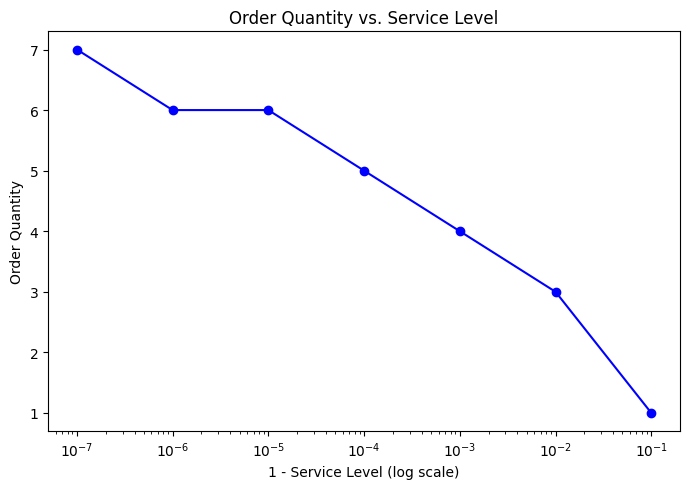

In [60]:
plt.figure(figsize=(7, 5))
plt.plot(1 - np.array(service_levels), order_quantities, marker='o', linestyle='-', color='blue')
plt.xscale('log')
# plt.xticks(service_levels, [f'{sl:.7f}' for sl in service_levels], rotation=45, ha='right')
plt.xlabel('1 - Service Level (log scale)')
plt.ylabel('Order Quantity')
plt.title('Order Quantity vs. Service Level')
# plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.show()
